In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pingouin as pg

from multipred.plotting import barplot_morey, analyze_attention_ROI, plot_decoding_nvoxels

In [3]:
PROJECT_PATH = "/media/wiseman/tocho/predrelv_fmri/"
DATA_PATH = f"{PROJECT_PATH}/group_analyses/multivariate/MVPA_proba/analyses/decoding_data/"
ROI = "earlyvisual"

## Comparing decoding across ROI sizes

24 subjects in 50 voxels mask. t(23)=4.1685, p=0.0001. Auditory modality: t(23)=1.8956, p=0.0642
23 subjects in 100 voxels mask. t(22)=5.2168, p=0.0000. Auditory modality: t(22)=3.7823, p=0.0005
23 subjects in 150 voxels mask. t(22)=6.3296, p=0.0000. Auditory modality: t(22)=3.8431, p=0.0004
23 subjects in 200 voxels mask. t(22)=6.4368, p=0.0000. Auditory modality: t(22)=5.1757, p=0.0000
23 subjects in 250 voxels mask. t(22)=7.1095, p=0.0000. Auditory modality: t(22)=5.3672, p=0.0000
23 subjects in 300 voxels mask. t(22)=7.8893, p=0.0000. Auditory modality: t(22)=5.3781, p=0.0000
23 subjects in 350 voxels mask. t(22)=7.6574, p=0.0000. Auditory modality: t(22)=4.7008, p=0.0000
25 subjects in funcloc voxels mask. t(24)=6.3015, p=0.0000. Auditory modality: t(24)=5.5070, p=0.0000
25 subjects in wholeROI voxels mask. t(24)=5.7348, p=0.0000. Auditory modality: t(24)=3.9183, p=0.0003


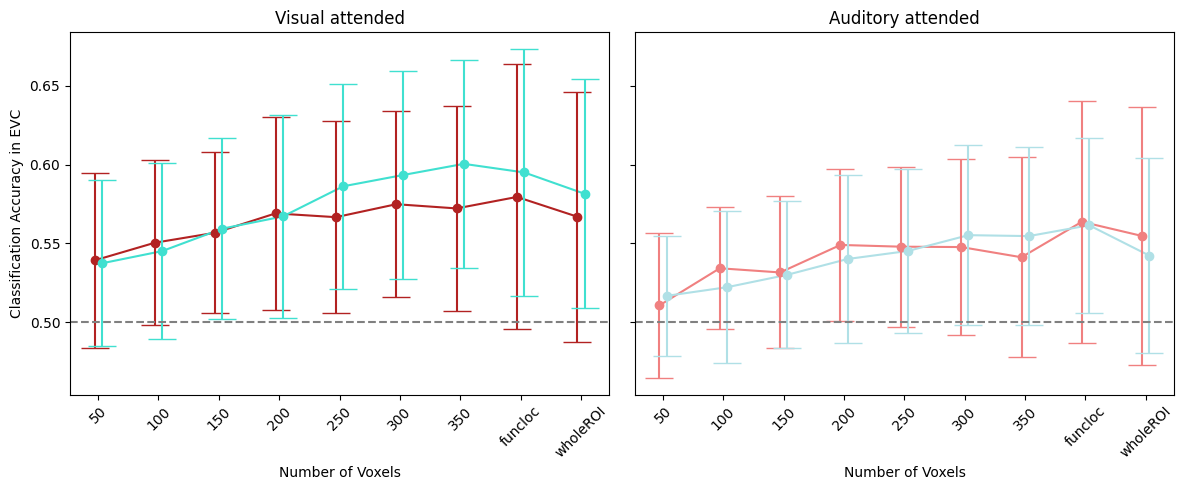

In [4]:
n_voxels_list = [
    "50",
    "100",
    "150",
    "200",
    "250",
    "300",
    "350",
    "funcloc",
    "wholeROI",
]
df_allROIs = plot_decoding_nvoxels(DATA_PATH, n_voxels_list, ROI, "v_pred")

## Analyze specific ROIs

In [7]:
ROI = "earlyvisual"
n_voxels = "350"
df = pd.read_csv(f"{DATA_PATH}/{ROI}_{n_voxels}/balanced_group_data.csv")
df_grouped = df.groupby(["subj", "modality", "a_pred", "v_pred"], as_index=False)[
    "correct"
].mean()

### Attention * visual prediction

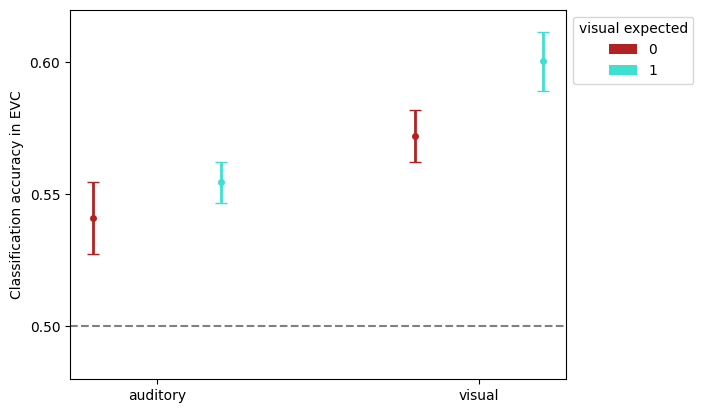

In [8]:
y = "correct"
x = "modality"
hue = "v_pred"
id = "subj"
dat = df.copy().groupby([id, x, hue], as_index=False)[y].mean()
barplot_morey(dat, x, y, hue, "visual expected", ["firebrick", "turquoise"], ["lightcoral", "powderblue"], False, False, False)
plt.xticks([0, 1], ["auditory", "visual"])
plt.ylabel(f"Classification accuracy in EVC")
plt.ylim(0.48, 0.62)
plt.yticks([0.5, 0.55, 0.6])
plt.axhline(0.5, color="grey", linestyle="--")

In [9]:
pg.rm_anova(dv=y, within=[x, hue], subject=id, data=dat.copy())

/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,modality,0.034013,1,22,0.034013,9.747833,0.004961,0.004961,0.067943,1.0
1,v_pred,0.010022,1,22,0.010022,3.684846,0.067971,0.067971,0.021027,1.0
2,modality * v_pred,0.001270,1,22,0.001270,0.711739,0.407947,0.407947,0.002715,1.0


In [10]:
pg.pairwise_tests(dv=y, within=[x, hue], subject=id, data=dat, padjust="fdr_bh")

,Contrast,modality,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,modality,-,auditory,visual,True,True,-3.122152,22.0,two-sided,0.004961,NaN,NaN,8.875,-0.584878
1,v_pred,-,0,1,True,True,-1.919595,22.0,two-sided,0.067971,NaN,NaN,1.04,-0.325053
2,modality * v_pred,auditory,0,1,True,True,-0.919806,22.0,two-sided,0.367650,0.367650,fdr_bh,0.32,-0.190032
3,modality * v_pred,visual,0,1,True,True,-2.120791,22.0,two-sided,0.045449,0.090898,fdr_bh,1.424,-0.366221


### Multimodal analyses

/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subject_mean'] = dat.groupby('subj')[y].transform('mean

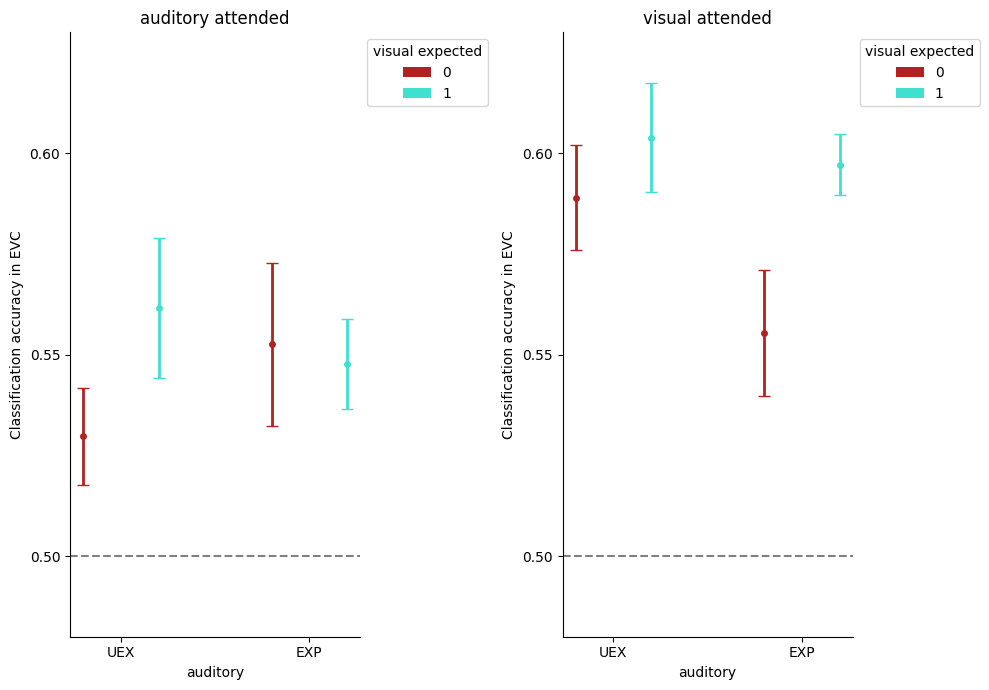

In [11]:
y = "correct"
x = "a_pred"
hue = "v_pred"
id = "subj"
ROI = "EVC"
save_fig = False
ylim = (0.48, 0.63)
yticks = [0.5, 0.55, 0.6]

anova_df, posthoc_df = analyze_attention_ROI(
    df_grouped, y, x, hue, "visual expected", id, ROI, save_fig, ylim, yticks
)

In [12]:
anova_df

,level_0,level_1,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,auditory attended,0,a_pred,0.000446,1,22,0.000446,0.058334,0.811386,0.811386,0.000647,1.0
1,auditory attended,1,v_pred,0.004156,1,22,0.004156,0.846043,0.367650,0.367650,0.005997,1.0
2,auditory attended,2,a_pred * v_pred,0.007746,1,22,0.007746,1.785754,0.195103,0.195103,0.011119,1.0
3,visual attended,0,a_pred,0.009393,1,22,0.009393,2.169551,0.154931,0.154931,0.013907,1.0
4,visual attended,1,v_pred,0.018428,1,22,0.018428,4.497756,0.045449,0.045449,0.026925,1.0
5,visual attended,2,a_pred * v_pred,0.004128,1,22,0.004128,1.443520,0.242346,0.242346,0.006160,1.0


In [13]:
posthoc_df

,level_0,level_1,Contrast,a_pred,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,auditory attended,0,a_pred,-,0,1,True,True,-0.241524,22.0,two-sided,0.811386,NaN,NaN,0.225,-0.058258
1,auditory attended,1,v_pred,-,0,1,True,True,-0.919806,22.0,two-sided,0.367650,NaN,NaN,0.32,-0.190032
2,auditory attended,2,a_pred * v_pred,0,0,1,True,True,-1.736957,22.0,two-sided,0.096378,0.192756,fdr_bh,0.797,-0.339991
3,auditory attended,3,a_pred * v_pred,1,0,1,True,True,0.226629,22.0,two-sided,0.822805,0.822805,fdr_bh,0.224,0.056832
4,visual attended,0,a_pred,-,0,1,True,True,1.472940,22.0,two-sided,0.154931,NaN,NaN,0.563,0.260148
5,visual attended,1,v_pred,-,0,1,True,True,-2.120791,22.0,two-sided,0.045449,NaN,NaN,1.424,-0.366221
6,visual attended,2,a_pred * v_pred,0,0,1,True,True,-0.812550,22.0,two-sided,0.425182,0.425182,fdr_bh,0.294,-0.162118
7,visual attended,3,a_pred * v_pred,1,0,1,True,True,-2.546172,22.0,two-sided,0.018407,0.036815,fdr_bh,2.956,-0.491086
